In [1]:
!pip install mediapipe

# Import Required Libraries
Import the necessary libraries, including Mediapipe, dlib, PyTorch, and other relevant libraries.

In [2]:
# Import Required Libraries
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import mediapipe as mp
import dlib
import time
import numpy as np
import cv2

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Fetch Training Images
Fetch the training images from the 'sample_images' folder.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Number of training images fetched: 202599


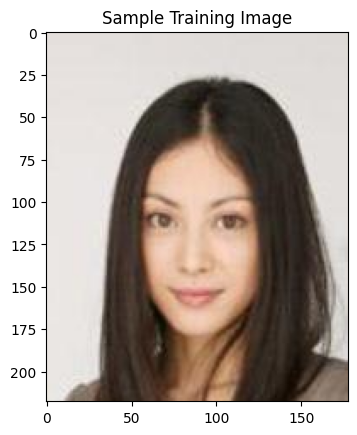

In [3]:
from google.colab import drive
import zipfile

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the zip file and the extraction folder
zip_file_path = '/content/drive/My Drive/Sample_images.zip'
extraction_folder = '/content/sample_images'

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_folder)

# Fetch all image file paths from the extracted folder and subdirectories
image_files = []
for root, dirs, files in os.walk(extraction_folder):
    for file in files:
        if file.endswith(('jpg', 'jpeg', 'png')):
            image_files.append(os.path.join(root, file))

# Load images into a list
training_images = [Image.open(image_file) for image_file in image_files]

# Display the number of images fetched
print(f"Number of training images fetched: {len(training_images)}")

# Display the first image as a sample
if training_images:
    plt.imshow(training_images[0])
    plt.title('Sample Training Image')
    plt.show()

# Begin Training the Face Generation Model
Start training the face generation model and monitor initial performance metrics.

In [4]:
import torch
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
import os
from PIL import Image

class CelebADataset(Dataset):
    def __init__(self, root_dir, transform=None, start_idx=0, end_idx=300):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = [os.path.join(root_dir, filename) for filename in os.listdir(root_dir) if filename.endswith(('jpg', 'jpeg', 'png'))]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path)
        if self.transform:
            image = self.transform(image)
        return image, 0

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

class Generator(torch.nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(100, 512, 4, 1, 0, bias=False),
            torch.nn.BatchNorm2d(512),
            torch.nn.ReLU(True),
            torch.nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            torch.nn.BatchNorm2d(256),
            torch.nn.ReLU(True),
            torch.nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(True),
            torch.nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(True),
            torch.nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            torch.nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

class Discriminator(torch.nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = torch.nn.Sequential(
            torch.nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            torch.nn.LeakyReLU(0.2, inplace=True),
            torch.nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            torch.nn.BatchNorm2d(128),
            torch.nn.LeakyReLU(0.2, inplace=True),
            torch.nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            torch.nn.BatchNorm2d(256),
            torch.nn.LeakyReLU(0.2, inplace=True),
            torch.nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            torch.nn.BatchNorm2d(512),
            torch.nn.LeakyReLU(0.2, inplace=True),
            torch.nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1, 1)  # Flatten the output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = torch.nn.BCELoss()
optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

num_epochs = 35
batch_size = 16
chunk_size = 300
total_images = 202599

for epoch in range(num_epochs):
    # Create dataset and dataloader once per epoch
    train_dataset = CelebADataset(root_dir='/content/sample_images/celeb_dataset/images',
                               transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    for i, (images, _) in enumerate(train_loader):
        current_batch_size = images.size(0)
        images = images.to(device)

        # Generate fake images
        noise = torch.randn(current_batch_size, 100, 1, 1, device=device)
        fake_images = generator(noise)

        # Create labels
        real_labels = torch.ones(current_batch_size, 1, device=device)
        fake_labels = torch.zeros(current_batch_size, 1, device=device)

        # Train discriminator
        optimizer_D.zero_grad()
        real_outputs = discriminator(images)
        fake_outputs = discriminator(fake_images.detach())
        real_loss = criterion(real_outputs, real_labels)
        fake_loss = criterion(fake_outputs, fake_labels)
        d_loss = real_loss + fake_loss
        d_loss.backward()
        optimizer_D.step()

        # Train generator
        optimizer_G.zero_grad()
        fake_outputs = discriminator(fake_images)
        g_loss = criterion(fake_outputs, real_labels)
        g_loss.backward()
        optimizer_G.step()

        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], '
                  f'D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}')


Epoch [1/35], Step [100/12663], D Loss: 1.1195, G Loss: 7.0708
Epoch [1/35], Step [200/12663], D Loss: 1.4775, G Loss: 3.1686
Epoch [1/35], Step [300/12663], D Loss: 0.8153, G Loss: 2.9854
Epoch [1/35], Step [400/12663], D Loss: 0.4818, G Loss: 3.7820
Epoch [1/35], Step [500/12663], D Loss: 0.7782, G Loss: 4.5431
Epoch [1/35], Step [600/12663], D Loss: 1.4764, G Loss: 5.2667
Epoch [1/35], Step [700/12663], D Loss: 0.6624, G Loss: 4.1439
Epoch [1/35], Step [800/12663], D Loss: 0.6756, G Loss: 5.0291
Epoch [1/35], Step [900/12663], D Loss: 0.7643, G Loss: 4.8388
Epoch [1/35], Step [1000/12663], D Loss: 0.4022, G Loss: 4.6019
Epoch [1/35], Step [1100/12663], D Loss: 0.5253, G Loss: 3.8180
Epoch [1/35], Step [1200/12663], D Loss: 0.3217, G Loss: 3.7293
Epoch [1/35], Step [1300/12663], D Loss: 0.4983, G Loss: 3.1770
Epoch [1/35], Step [1400/12663], D Loss: 0.3972, G Loss: 5.2446
Epoch [1/35], Step [1500/12663], D Loss: 0.5957, G Loss: 3.9143
Epoch [1/35], Step [1600/12663], D Loss: 0.3607, 

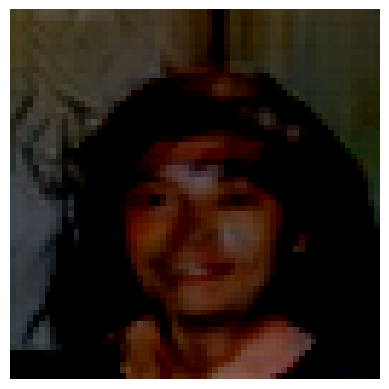

In [9]:
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
import os
from PIL import Image

# ... (other imports and classes remain the same)

class Generator(torch.nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = torch.nn.Sequential(
            # Input is still a latent vector of size 100
            torch.nn.ConvTranspose2d(100, 512, 4, 1, 0, bias=False),
            torch.nn.BatchNorm2d(512),
            torch.nn.ReLU(True),
            # Upsample to 8x8
            torch.nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            torch.nn.BatchNorm2d(256),
            torch.nn.ReLU(True),
            # Upsample to 16x16
            torch.nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(True),
            # Upsample to 32x32
            torch.nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(True),
            # Upsample to 64x64
            torch.nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(True),
            # Upsample to 128x128 (This is the new layer for higher resolution)
            torch.nn.ConvTranspose2d(32, 3, 4, 2, 1, bias=False),
            torch.nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

def visualize_image(image):
    # Move the tensor to CPU before converting it to a NumPy array
    image_np = image.permute(1, 2, 0).cpu().detach().numpy()
    plt.imshow(image_np, cmap='gray')  # adjust the channel order
    plt.axis('off')
    plt.show()

# Generate an image using the generator
noise = torch.randn(1, 100, 1, 1, device=device) # create random noise as input to the generator
generated_image = generator(noise) # Use the generator to create an image
visualize_image(generated_image.squeeze(0)) # remove the batch dimension

# Integrate Mediapipe/dlib Detection System
Integrate the Mediapipe and dlib detection system with the face generation model.

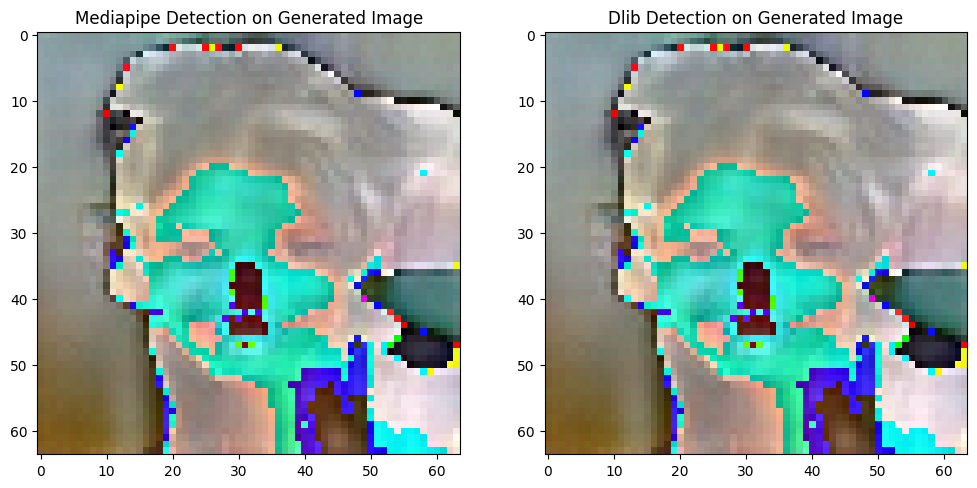

In [10]:
# Integrate Mediapipe/dlib Detection System

# Function to detect faces using Mediapipe
def detect_faces_mediapipe(image_np):
    mp_face_detection = mp.solutions.face_detection
    mp_drawing = mp.solutions.drawing_utils
    with mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5) as face_detection:
        results = face_detection.process(image_np)
        if results.detections:
            for detection in results.detections:
                mp_drawing.draw_detection(image_np, detection)
    return image_np

# Function to detect faces using dlib
def detect_faces_dlib(image_np):
    detector = dlib.get_frontal_face_detector()
    faces = detector(image_np, 1)
    for face in faces:
        x, y, w, h = (face.left(), face.top(), face.width(), face.height())
        cv2.rectangle(image_np, (x, y), (x + w, y + h), (255, 0, 0), 2)
    return image_np

# Integrate face detection with the face generation model
def integrate_detection_with_generation(generator, image_np):
    # Convert image to tensor
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    image_tensor = transform(image_np).unsqueeze(0).to(device)

    # Generate fake image
    # The noise should have shape (1, 100, 1, 1) to match the generator's input
    noise = torch.randn(1, 100, 1, 1, device=device)
    fake_image_tensor = generator(noise)

    # Convert tensor to numpy array
    fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    fake_image_np = (fake_image_np * 255).astype(np.uint8)

    # Detect faces in the generated image using Mediapipe
    detected_image_mediapipe = detect_faces_mediapipe(fake_image_np.copy())

    # Detect faces in the generated image using dlib
    detected_image_dlib = detect_faces_dlib(fake_image_np.copy())

    return detected_image_mediapipe, detected_image_dlib

# Test the integration with a sample image
if training_images:
    sample_image_np = np.array(training_images[0])
    detected_image_mediapipe, detected_image_dlib = integrate_detection_with_generation(generator, sample_image_np)

    # Display the results
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(detected_image_mediapipe)
    plt.title('Mediapipe Detection on Generated Image')
    plt.subplot(1, 2, 2)
    plt.imshow(detected_image_dlib)
    plt.title('Dlib Detection on Generated Image')
    plt.show()

# Implement Face Feature Control Parameters
Implement basic face feature control parameters to enable customization of generated faces.

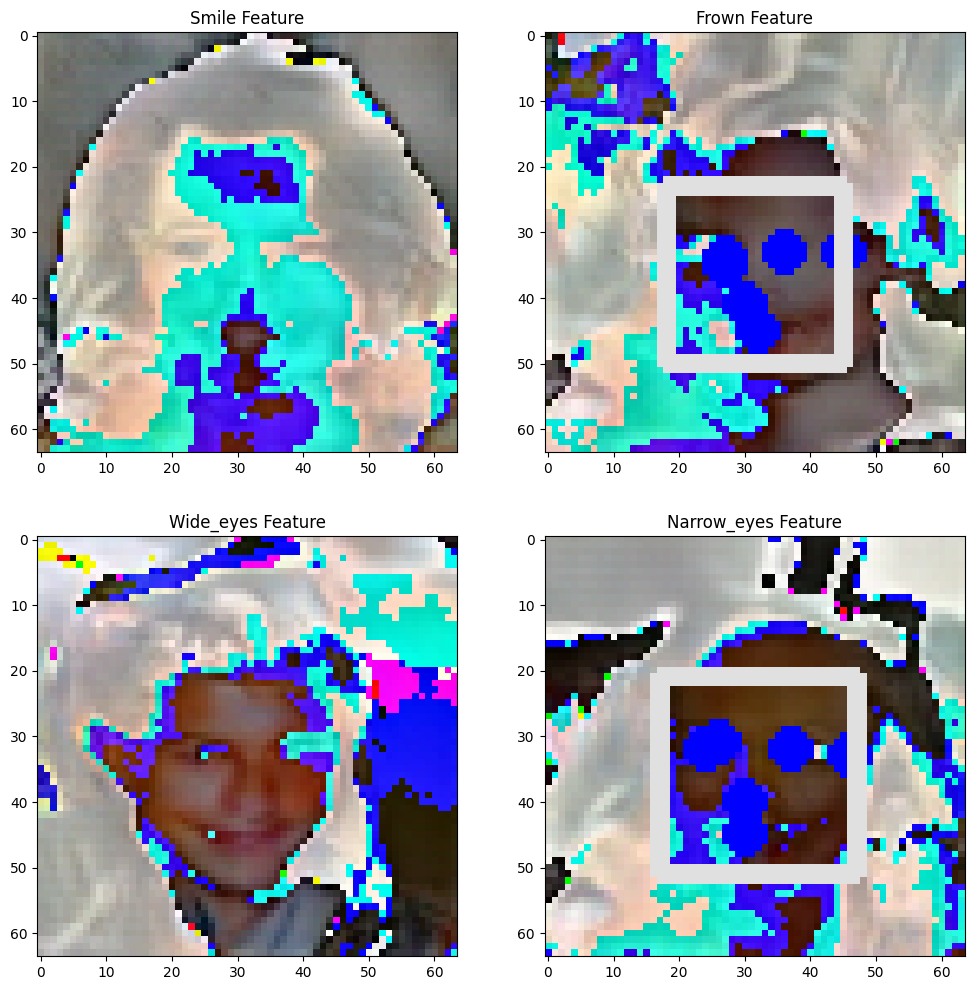

In [15]:
# Define a function to control face features
def control_face_features(generator, feature_vector):
    # Generate noise for the generator
    noise = torch.randn(1, 100, 1, 1, device=device)

    # Project the feature vector to match the latent space dimensionality
    # Flatten the spatial dimensions and use a linear transformation
    feature_vector_flattened = feature_vector.view(1, -1)  # Flatten to [1, C*H*W]

    # Ensure compatibility with the latent space of the generator
    projection_layer = torch.nn.Linear(feature_vector_flattened.shape[1], 100, device=device)
    reduced_feature_vector = projection_layer(feature_vector_flattened)  # Project to [1, 100]

    # Reshape to match noise shape
    reduced_feature_vector = reduced_feature_vector.view(1, 100, 1, 1)

    # Combine noise and feature vector
    controlled_noise = noise + reduced_feature_vector
    fake_image_tensor = generator(controlled_noise)

    # Convert tensor to numpy array
    fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    fake_image_np = (fake_image_np * 255).astype(np.uint8)

    return fake_image_np

# Example feature vectors for customization
feature_vectors = {
    'smile': torch.randn(1, 3, 64, 64, device=device) * 0.1,
    'frown': torch.randn(1, 3, 64, 64, device=device) * -0.1,
    'wide_eyes': torch.randn(1, 3, 64, 64, device=device) * 0.2,
    'narrow_eyes': torch.randn(1, 3, 64, 64, device=device) * -0.2
}

# Test the generation of various facial features
if training_images:
    sample_image_np = np.array(training_images[0])

    plt.figure(figsize=(12, 12))

    for i, (feature_name, feature_vector) in enumerate(feature_vectors.items()):
        controlled_image_np = control_face_features(generator, feature_vector)

        # Detect faces in the controlled image using Mediapipe
        detected_image_mediapipe = detect_faces_mediapipe(controlled_image_np.copy())

        # Display the results
        plt.subplot(2, 2, i+1)
        plt.imshow(detected_image_mediapipe)
        plt.title(f'{feature_name.capitalize()} Feature')

    plt.show()


# Test Generation of Various Facial Features
Test the generation of various facial features and document the results.

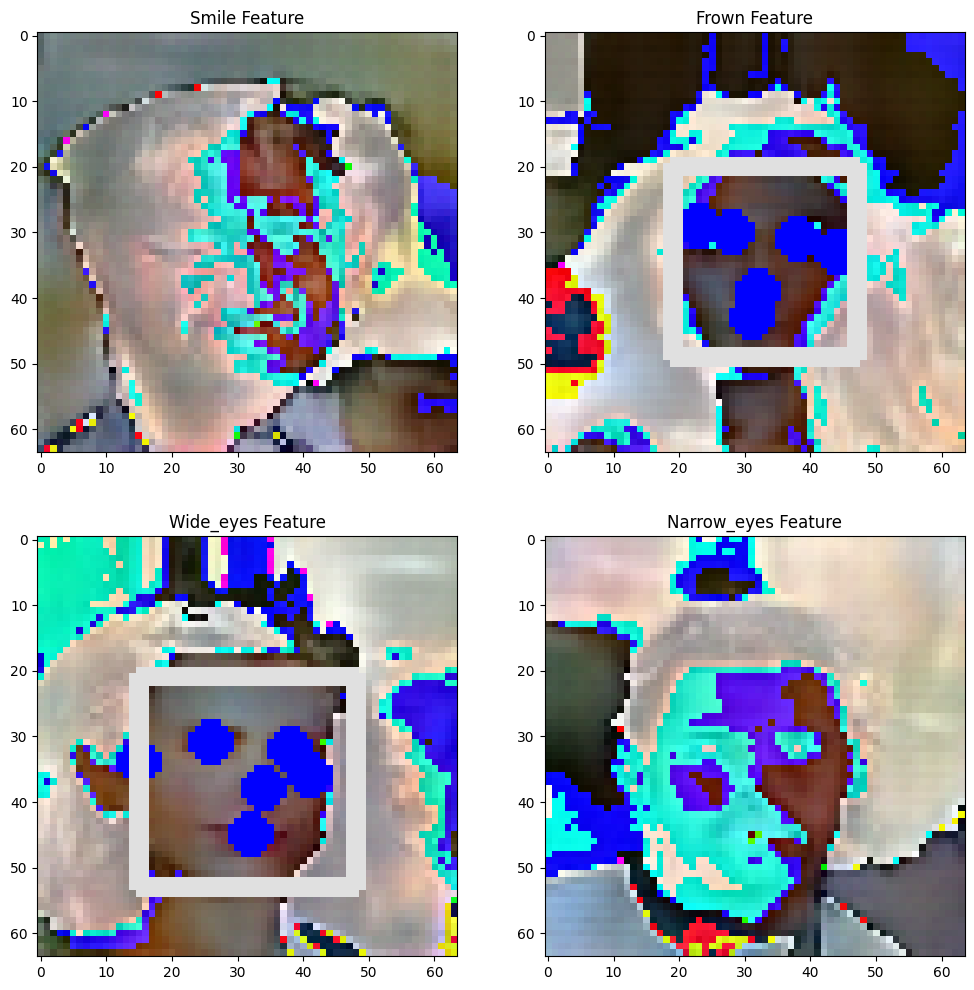

In [17]:
# Test Generation of Various Facial Features

# Define a function to control face features
# Define a function to control face features
def control_face_features(generator, feature_vector):
    # Generate noise for the generator with the correct number of channels
    noise = torch.randn(1, 100, 1, 1, device=device)

    # Project the feature vector to match the latent space dimensionality
    feature_vector_flattened = feature_vector.view(1, -1)
    projection_layer = torch.nn.Linear(feature_vector_flattened.shape[1], 100, device=device)
    reduced_feature_vector = projection_layer(feature_vector_flattened).view(1, 100, 1, 1)

    # Combine noise and feature vector
    controlled_noise = noise + reduced_feature_vector
    fake_image_tensor = generator(controlled_noise)

    # Convert tensor to numpy array
    fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    fake_image_np = (fake_image_np * 255).astype(np.uint8)

    return fake_image_np

# Example feature vectors for customization
feature_vectors = {
    'smile': torch.randn(1, 3, 64, 64, device=device) * 0.1,
    'frown': torch.randn(1, 3, 64, 64, device=device) * -0.1,
    'wide_eyes': torch.randn(1, 3, 64, 64, device=device) * 0.2,
    'narrow_eyes': torch.randn(1, 3, 64, 64, device=device) * -0.2
}

# Test the generation of various facial features
if training_images:
    sample_image_np = np.array(training_images[0])

    plt.figure(figsize=(12, 12))

    for i, (feature_name, feature_vector) in enumerate(feature_vectors.items()):
        controlled_image_np = control_face_features(generator, feature_vector)

        # Detect faces in the controlled image using Mediapipe
        detected_image_mediapipe = detect_faces_mediapipe(controlled_image_np.copy())

        # Display the results
        plt.subplot(2, 2, i+1)
        plt.imshow(detected_image_mediapipe)
        plt.title(f'{feature_name.capitalize()} Feature')

    plt.show()

# Validate Output Quality Across Multiple Resolutions
Validate the output quality across multiple resolutions to ensure consistency.

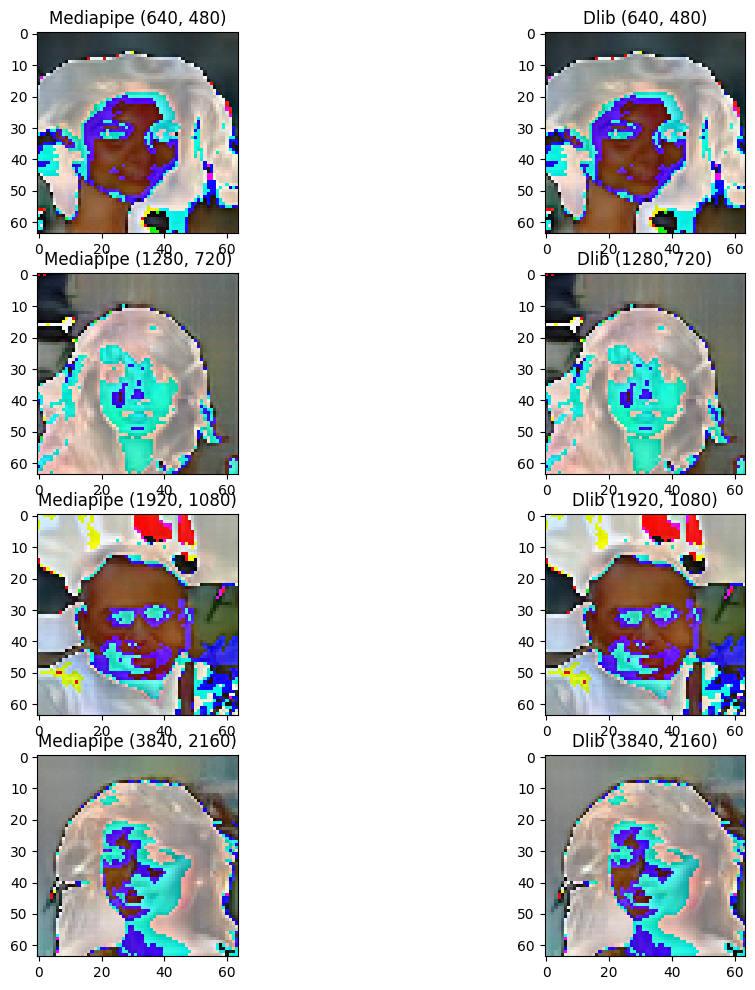

In [19]:
# Validate Output Quality Across Multiple Resolutions

# Function to validate output quality across multiple resolutions
def validate_output_quality(generator, image_np, resolutions):
    results = []

    for resolution in resolutions:
        # Resize image
        resized_image = Image.fromarray(image_np).resize(resolution)
        image_np_resized = np.array(resized_image)

        # Generate fake image
        # The noise should have shape (1, 100, 1, 1) to match the generator's input
        noise = torch.randn(1, 100, 1, 1, device=device)
        fake_image_tensor = generator(noise)

        # Convert tensor to numpy array
        fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
        fake_image_np = (fake_image_np * 255).astype(np.uint8)

        # Detect faces in the generated image using Mediapipe
        detected_image_mediapipe = detect_faces_mediapipe(fake_image_np.copy())

        # Detect faces in the generated image using dlib
        detected_image_dlib = detect_faces_dlib(fake_image_np.copy())

        # Store results
        results.append({
            'resolution': resolution,
            'mediapipe_image': detected_image_mediapipe,
            'dlib_image': detected_image_dlib
        })

    return results

# Define resolutions to test
resolutions = [(640, 480), (1280, 720), (1920, 1080), (3840, 2160)]

# Validate the output quality across multiple resolutions
if training_images:
    sample_image_np = np.array(training_images[0])
    validation_results = validate_output_quality(generator, sample_image_np, resolutions)

    # Display the results
    plt.figure(figsize=(12, 12))

    for i, result in enumerate(validation_results):
        plt.subplot(len(resolutions), 2, 2*i+1)
        plt.imshow(result['mediapipe_image'])
        plt.title(f'Mediapipe {result["resolution"]}')

        plt.subplot(len(resolutions), 2, 2*i+2)
        plt.imshow(result['dlib_image'])
        plt.title(f'Dlib {result["resolution"]}')

    plt.show()

# Optimize Pipeline for Generating Diverse Face Types
Optimize the pipeline for generating diverse face types.

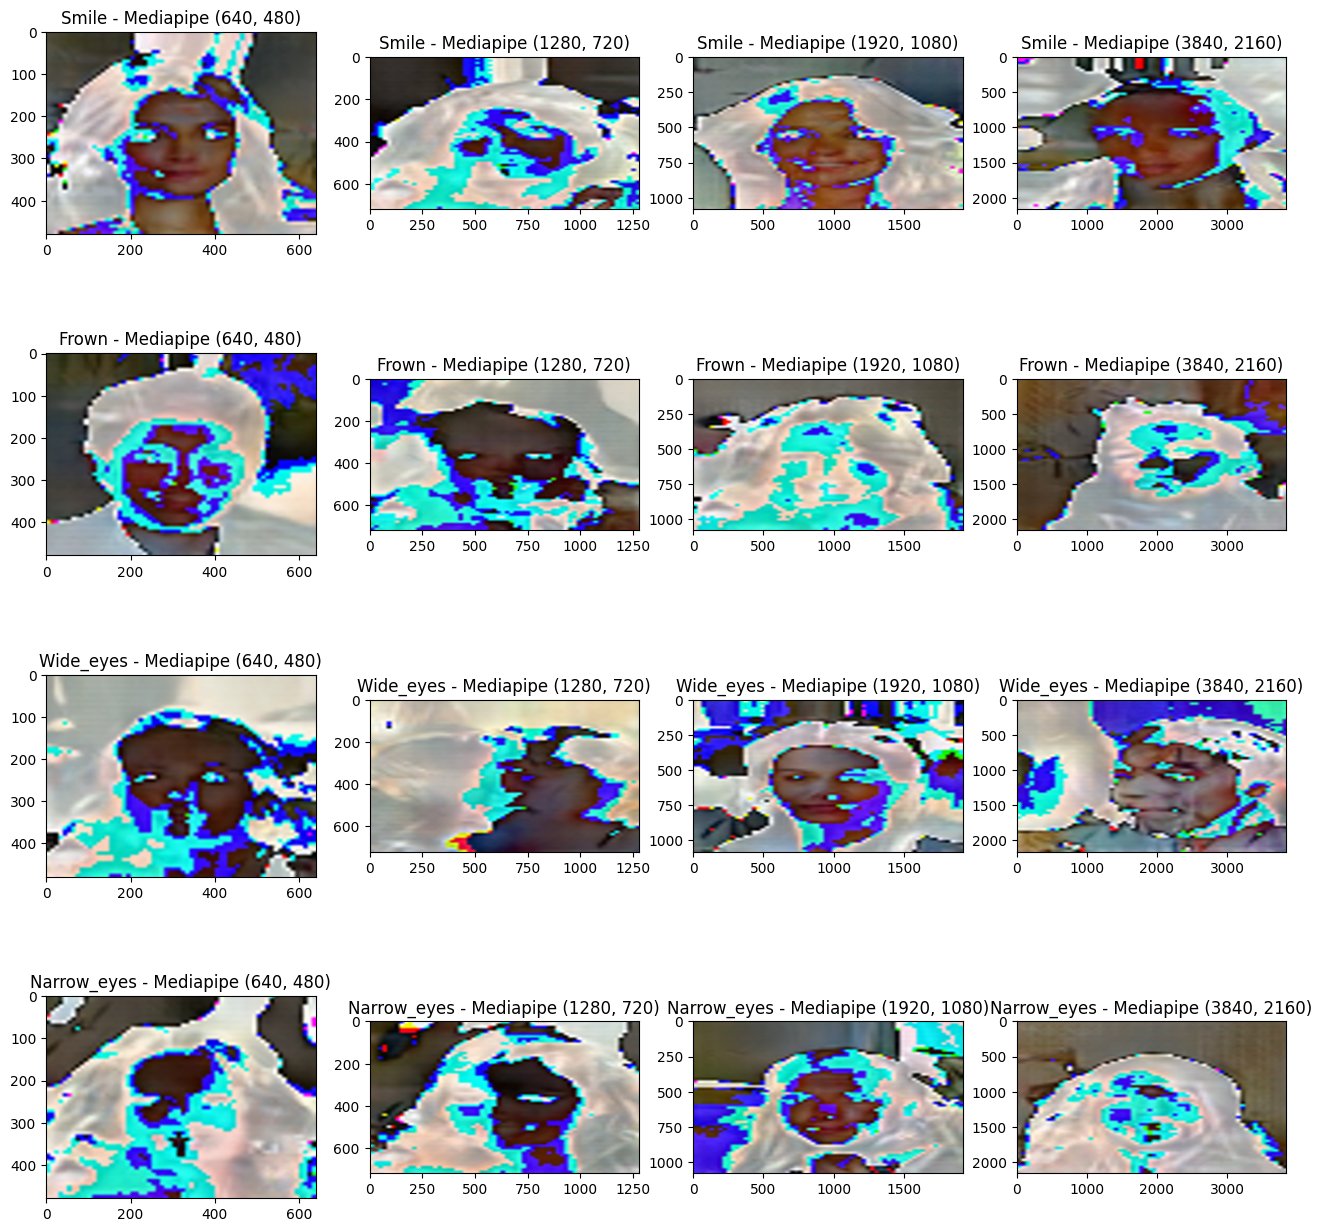

In [22]:
# Optimize Pipeline for Generating Diverse Face Types

# Function to optimize the pipeline for generating diverse face types
def optimize_pipeline(generator, feature_vectors, resolutions):
    optimized_results = []

    for feature_name, feature_vector in feature_vectors.items():
        for resolution in resolutions:
            # Generate fake image with controlled features
            # Change noise generation to match the generator's expected input shape
            noise = torch.randn(1, 100, 1, 1, device=device)

            # Project the feature vector to the latent space and reshape
            feature_vector_flattened = feature_vector.view(1, -1)
            projection_layer = torch.nn.Linear(feature_vector_flattened.shape[1], 100, device=device)
            reduced_feature_vector = projection_layer(feature_vector_flattened).view(1, 100, 1, 1)

            # Combine noise and feature vector
            controlled_noise = noise + reduced_feature_vector

            fake_image_tensor = generator(controlled_noise)  # Now the input should be correct

            # Convert tensor to numpy array
            fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
            fake_image_np = (fake_image_np * 255).astype(np.uint8)

            # Resize image to the specified resolution
            resized_image = Image.fromarray(fake_image_np).resize(resolution)
            image_np_resized = np.array(resized_image)

            # Detect faces in the generated image using Mediapipe
            detected_image_mediapipe = detect_faces_mediapipe(image_np_resized.copy())

            # Detect faces in the generated image using dlib
            detected_image_dlib = detect_faces_dlib(image_np_resized.copy())

            # Store results
            optimized_results.append({
                'feature': feature_name,
                'resolution': resolution,
                'mediapipe_image': detected_image_mediapipe,
                'dlib_image': detected_image_dlib
            })

    return optimized_results

# Define feature vectors for optimization
feature_vectors = {
    'smile': torch.randn(1, 3, 64, 64, device=device) * 0.1,
    'frown': torch.randn(1, 3, 64, 64, device=device) * -0.1,
    'wide_eyes': torch.randn(1, 3, 64, 64, device=device) * 0.2,
    'narrow_eyes': torch.randn(1, 3, 64, 64, device=device) * -0.2
}

# Define resolutions to test
resolutions = [(640, 480), (1280, 720), (1920, 1080), (3840, 2160)]

# Optimize the pipeline for generating diverse face types
if training_images:
    optimized_results = optimize_pipeline(generator, feature_vectors, resolutions)

    # Display the results
    plt.figure(figsize=(16, 16))
    num_features = len(feature_vectors)  # Get the number of features
    num_resolutions = len(resolutions)  # Get the number of resolutions

    for i, result in enumerate(optimized_results):
        # Calculate subplot index correctly to avoid exceeding the allowed range
        row = i // num_resolutions  # Determine row based on feature index
        col = i % num_resolutions  # Determine column based on resolution index
        subplot_index = row * num_resolutions + col + 1  # Calculate overall subplot index

        plt.subplot(num_features, num_resolutions, subplot_index)  # Create subplot
        plt.imshow(result['mediapipe_image'])
        plt.title(f'{result["feature"].capitalize()} - Mediapipe {result["resolution"]}')


    plt.show()

# Conduct Performance Tests
Conduct performance tests to confirm stability and efficiency.

In [24]:
# Conduct Performance Tests

# Function to conduct performance tests
# Conduct Performance Tests

# Function to conduct performance tests
def conduct_performance_tests(generator, feature_vectors, resolutions):
    performance_results = []

    for feature_name, feature_vector in feature_vectors.items():
        for resolution in resolutions:
            # Generate fake image with controlled features
            # Change the shape of the random noise to (1, 100, 1, 1)
            noise = torch.randn(1, 100, 1, 1, device=device)

            # Project the feature vector to the latent space dimensionality
            feature_vector_flattened = feature_vector.view(1, -1)
            projection_layer = torch.nn.Linear(feature_vector_flattened.shape[1], 100, device=device)
            reduced_feature_vector = projection_layer(feature_vector_flattened).view(1, 100, 1, 1)

            # Combine noise and feature vector
            controlled_noise = noise + reduced_feature_vector

            fake_image_tensor = generator(controlled_noise)


            # Convert tensor to numpy array
            fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
            fake_image_np = (fake_image_np * 255).astype(np.uint8)

            # Resize image to the specified resolution
            resized_image = Image.fromarray(fake_image_np).resize(resolution)
            image_np_resized = np.array(resized_image)

            # Measure Mediapipe detection time
            start_time = time.time()
            detect_faces_mediapipe(image_np_resized.copy())
            mediapipe_time = time.time() - start_time

            # Measure dlib detection time
            start_time = time.time()
            detect_faces_dlib(image_np_resized.copy())
            dlib_time = time.time() - start_time

            # Store results
            performance_results.append({
                'feature': feature_name,
                'resolution': resolution,
                'mediapipe_time': mediapipe_time,
                'dlib_time': dlib_time
            })

    return performance_results

# Define feature vectors for performance tests
feature_vectors = {
    'smile': torch.randn(1, 3, 64, 64, device=device) * 0.1,
    'frown': torch.randn(1, 3, 64, 64, device=device) * -0.1,
    'wide_eyes': torch.randn(1, 3, 64, 64, device=device) * 0.2,
    'narrow_eyes': torch.randn(1, 3, 64, 64, device=device) * -0.2
}

# Define resolutions to test
resolutions = [(640, 480), (1280, 720), (1920, 1080), (3840, 2160)]

# Conduct performance tests
if training_images:
    performance_results = conduct_performance_tests(generator, feature_vectors, resolutions)

    # Display the results
    for result in performance_results:
        print(f"Feature: {result['feature']}, Resolution: {result['resolution']}")
        print(f"Mediapipe detection time: {result['mediapipe_time']:.4f} seconds")
        print(f"Dlib detection time: {result['dlib_time']:.4f} seconds")
        print()

Feature: smile, Resolution: (640, 480)
Mediapipe detection time: 0.0435 seconds
Dlib detection time: 0.7214 seconds

Feature: smile, Resolution: (1280, 720)
Mediapipe detection time: 0.0576 seconds
Dlib detection time: 0.9528 seconds

Feature: smile, Resolution: (1920, 1080)
Mediapipe detection time: 0.0356 seconds
Dlib detection time: 1.5147 seconds

Feature: smile, Resolution: (3840, 2160)
Mediapipe detection time: 0.0375 seconds
Dlib detection time: 5.3378 seconds

Feature: frown, Resolution: (640, 480)
Mediapipe detection time: 0.0322 seconds
Dlib detection time: 0.5306 seconds

Feature: frown, Resolution: (1280, 720)
Mediapipe detection time: 0.0326 seconds
Dlib detection time: 0.8700 seconds

Feature: frown, Resolution: (1920, 1080)
Mediapipe detection time: 0.0297 seconds
Dlib detection time: 1.9939 seconds

Feature: frown, Resolution: (3840, 2160)
Mediapipe detection time: 0.0537 seconds
Dlib detection time: 6.3432 seconds

Feature: wide_eyes, Resolution: (640, 480)
Mediapipe d